In [165]:
%load_ext autoreload
%autoreload 2
from dig4bio.io import read_raman_file
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from dig4bio.constants import ALL_DEVICE_NAMES
from matplotlib.lines import Line2D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
dfs = {device: read_raman_file(device,level='interim') for device in ALL_DEVICE_NAMES}
dfs['anton532']

,200.0,202.0,204.0,206.0,208.0,210.0,212.0,214.0,216.0,218.0,...,3492.0,3494.0,3496.0,3498.0,3500.0,glucose,Na_acetate,Mg_SO4,MSM_present,fold_idx
0,7519.06,7582.15,7379.73,7054.04,6818.64,6684.24,6562.20,6398.03,6256.17,6135.72,...,6573.45,6488.44,6284.99,6216.51,6409.21,0.26335,1.43570,1.44101,0.0,0
1,7414.24,7502.98,7327.93,7002.97,6760.01,6638.17,6539.84,6360.47,6200.67,6080.42,...,6564.97,6465.79,6241.37,6171.89,6358.46,0.26335,1.43570,1.44101,0.0,0
2,7376.45,7474.90,7304.00,6961.46,6691.31,6557.30,6470.64,6309.66,6177.40,6090.05,...,6521.16,6452.89,6248.68,6137.06,6318.74,0.26335,1.43570,1.44101,0.0,0
3,7383.60,7456.90,7264.59,6938.71,6707.66,6594.61,6493.20,6307.50,6144.74,6033.89,...,6532.58,6459.36,6240.35,6146.15,6325.52,0.26335,1.43570,1.44101,0.0,0
4,7345.77,7435.40,7263.58,6929.82,6671.51,6544.19,6459.28,6302.71,6158.40,6043.02,...,6530.51,6435.62,6214.08,6156.26,6348.95,0.26335,1.43570,1.44101,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,7832.00,7938.65,7758.85,7401.53,7122.56,6982.76,6884.94,6702.59,6537.42,6417.34,...,7890.47,7786.45,7544.57,7448.89,7652.59,10.71080,0.74408,3.48079,0.0,4
266,7799.25,7874.64,7683.97,7335.51,7069.06,6933.33,6827.90,6633.28,6466.11,6358.28,...,7846.83,7756.49,7530.37,7427.52,7587.48,10.71080,0.74408,3.48079,0.0,4
267,7752.49,7823.53,7631.56,7311.92,7087.74,6973.90,6867.04,6686.11,6522.25,6391.02,...,7774.98,7694.02,7490.46,7377.11,7541.42,10.71080,0.74408,3.48079,0.0,4
268,7757.55,7803.91,7606.17,7295.83,7082.62,6976.21,6870.14,6678.14,6495.80,6352.90,...,7801.14,7693.90,7459.89,7372.70,7559.06,10.71080,0.74408,3.48079,0.0,4


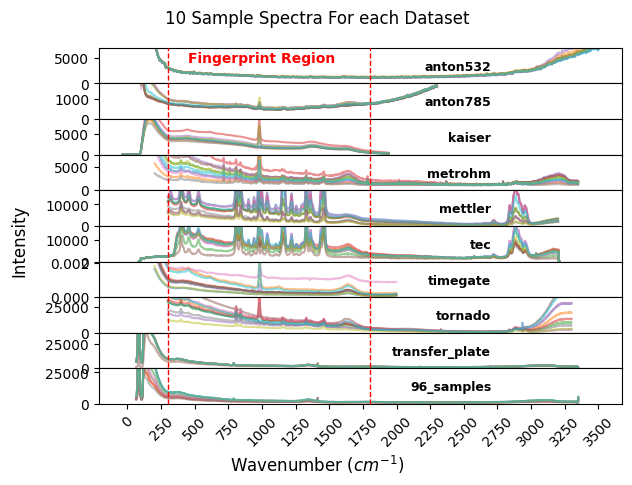

In [242]:
def generate_samples_plot(dfs: dict[str, pd.DataFrame], device_names: list[str]) ->plt.Figure:

    fig=plt.figure()
    gs = fig.add_gridspec(len(device_names), hspace=0)
    axs = gs.subplots(sharex=True, sharey=False)

    def plot_spectra_sample(ax, device:str) -> None:

        df_to_show = dfs[device]

        if device == 'transfer_plate':
            spectral_cols = df_to_show.columns[1:-4]
        elif device == '96_samples':
            spectral_cols = df_to_show.columns[1:]
        else:
            spectral_cols = df_to_show.columns[:-5]


        wavenumbers = spectral_cols.astype(float)
        df_sample = df_to_show.sample(10,random_state=90)
        spectra = df_sample[spectral_cols].to_numpy()

        ax.plot(wavenumbers,spectra.T,alpha=0.5)

        ax.set_ylim(0, np.nanpercentile(spectra, 98))

        ax.text(0.75,0.65,device,transform=ax.transAxes,ha="right",va="top",fontsize=9,fontweight="bold")

    def add_fingerprint_region(fig, axs, x_1,x_2, **kwargs):
        ax_ref = axs[-1]

        x_display_1 = ax_ref.transData.transform((x_1, 0))[0]
        x_display_2 = ax_ref.transData.transform((x_2, 0))[0]
        x_fig_1 = fig.transFigure.inverted().transform((x_display_1, 0))[0]
        x_fig_2 = fig.transFigure.inverted().transform((x_display_2, 0))[0]

        y0 = min(ax.get_position().y0 for ax in axs)
        y1 = max(ax.get_position().y1 for ax in axs)

        line_1 = Line2D([x_fig_1, x_fig_1],[y0, y1],transform=fig.transFigure,**kwargs)
        line_2 = Line2D([x_fig_2, x_fig_2],[y0, y1],transform=fig.transFigure,**kwargs)
        fig.add_artist(line_1)
        fig.add_artist(line_2)

        axs[0].text(1000,4000,'Fingerprint Region',color='red',fontweight="bold",ha='center')

    for ax, device in zip(axs, device_names):
        plot_spectra_sample(ax, device)

    for ax in axs:
        ax.label_outer()

    fig.supxlabel("Wavenumber $(cm^{-1})$")
    fig.supylabel("Intensity")
    fig.suptitle("10 Sample Spectra For each Dataset")

    fig.tight_layout()

    add_fingerprint_region(fig,axs,300,1800,color="red",linestyle="--",linewidth=1)

    axs[-1].set_xticks(np.arange(0,3501,250,))
    axs[-1].tick_params(axis="x", labelrotation=45)

    plt.close(fig)
    return fig

fig = generate_samples_plot(dfs= dfs,device_names = ALL_DEVICE_NAMES)

display(fig)
fig.savefig('plot.png',dpi=400)

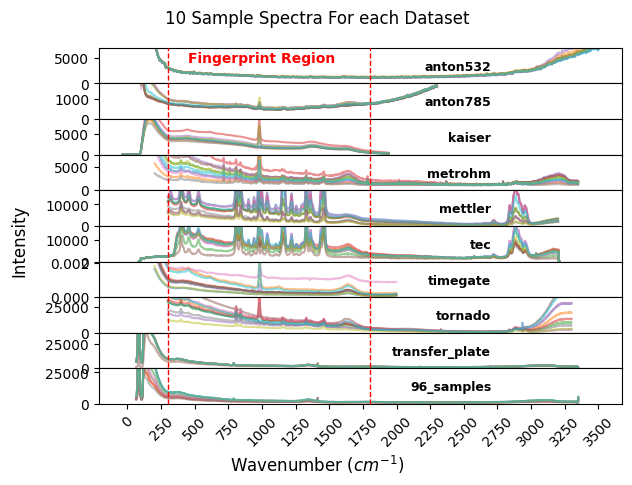

In [247]:
from dig4bio.visualisation import generate_samples_plot

fig = generate_samples_plot(dfs=dfs)
display(fig)